In [1]:
import os
from sklearn.pipeline import Pipeline
from model_class.feature_builder_clean_v2 import FeatureBuilder
from model_class.feature_builder_transformer import FeatureBuilderTransformer
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import SGDOneClassSVM
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import roc_auc_score, roc_curve


### 1. Import data

In [2]:
# Get the current directory
current_directory = os.getcwd()
    
# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_training_data.csv"
df_train = pd.read_csv(file, header=0)
y_train = df_train['evil']
X_train = df_train.drop(columns=['sus', 'evil'])

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_testing_data.csv"
df_test = pd.read_csv(file, header=0)
y_test = df_test['evil']
X_test = df_test.drop(columns=['sus', 'evil'])

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_validation_data.csv"
df_validation = pd.read_csv(file, header=0)
y_validation = df_validation['evil']
X_validation = df_validation.drop(columns=['sus', 'evil'])

In [3]:

def evaluate_model(y_true, y_pred, dataset_type="Dataset"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Get unique values and their counts in y_true
    unique_values, counts = np.unique(y_true, return_counts=True)
    print(f"y_true_{dataset_type} Unique values: {unique_values}")
    print(f"y_true_{dataset_type} Counts of each value: {counts}")

    # Get unique values and their counts in y_pred
    unique_values, counts = np.unique(y_pred, return_counts=True)
    print(f"y_pred_{dataset_type} Unique values: {unique_values}")
    print(f"y_pred_{dataset_type} Counts of each value: {counts}")

     # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print("Confusion Matrix:")
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Inlier", "Outlier"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {dataset_type}')
    plt.show()

    # ROC AUC Score
    roc_auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)

    print(f"False Positive Rate: {fpr}")
    print(f"True Positive Rate: {tpr}")


    if dataset_type == "Test Dataset":
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic for {dataset_type}')
        plt.legend(loc="lower right")
        plt.show()

### 2. build features and train the model

In [4]:
count_cols = [
    "processId_eventId_past_count",
    "processId_past_count",
    "threadId_past_count",
    "eventId_past_count",
    "userId_past_count",
    "parentProcessId_past_count",
    "mountNamespace_past_count",
]

rarity_cols = [
    "processId_eventId_rarity",
    "processId_rarity",
    "threadId_rarity",
    "eventId_rarity",
    "userId_rarity",
    "parentProcessId_rarity",
    "mountNamespace_rarity",
]

first_seen_cols = [
    "processId_eventId_is_first_seen",
    "processId_is_first_seen",
    "threadId_is_first_seen",
    "eventId_is_first_seen",
    "userId_is_first_seen",
    "parentProcessId_is_first_seen",
    "mountNamespace_is_first_seen",
]

scale_cols = [
    "stackAddresses_len",
    "stackAddresses_unique_ratio",
    "child_process_spawn_rate_so_far",
]

binary_cols = [
    "userId_binary",
    "parentUserId_binary",
]

passthrough_cols = [
    "argsNum",
    "returnValue",
    "returnValue_is_error",
    "args_has_path",
]

log_count_pipeline = Pipeline([
    ("log", FunctionTransformer(
        lambda x: np.log1p(np.clip(x, 0, None)),
        feature_names_out="one-to-one",
        validate=False
    )),
    ("scale", RobustScaler()),
])

rarity_pipeline = Pipeline([
    ("scale", RobustScaler()),
])

scale_pipeline = Pipeline([
    ("scale", RobustScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("count", log_count_pipeline, count_cols),
        ("rarity", rarity_pipeline, rarity_cols),
        ("first_seen", "passthrough", first_seen_cols),
        ("scale_other", scale_pipeline, scale_cols),
        ("binary", "passthrough", binary_cols),
        ("pass", "passthrough", passthrough_cols),
    ]
)

In [5]:
model = Pipeline([
    ("features", FeatureBuilderTransformer(FeatureBuilder(), return_numpy=False)),
    ("scaler", preprocessor),
    ("clf", SGDOneClassSVM(nu=0.05, random_state=42)),
])

In [6]:
X_train_transformed = model[:-1].fit_transform(X_train)
feature_names = model.named_steps["scaler"].get_feature_names_out()
X_train_arr = np.asarray(X_train_transformed)

for i, col in enumerate(feature_names):
    vals = X_train_arr[:, i]
    print(
        col,
        "min=", np.nanmin(vals),
        "max=", np.nanmax(vals),
        "std=", np.nanstd(vals)
    )

763144 rows before feature engineering
763144 rows after merging parent process info
763144 rows after frequency encoding
763144 Null value counts after imputation
parent_timestamp null value count: 434615
763144 rows after processing parent and child process info and relationship
763144 rows after processing stackAddresses info
763144 rows after processing arg info
count__processId_eventId_past_count min= -2.7608823111961103 max= 2.0545232353784657 std= 0.8071519549367815
count__processId_past_count min= -4.674991792139068 max= 2.5377696074199405 std= 0.9057030631291093
count__threadId_past_count min= -4.624797066434414 max= 2.513874450765247 std= 0.904778883342952
count__eventId_past_count min= -5.568699571632947 max= 1.0081949956073155 std= 0.8902074579459124
count__userId_past_count min= -8.57563136601773 max= 1.0358509690923985 std= 0.9884060979674777
count__parentProcessId_past_count min= -5.382273351106752 max= 1.0013728140937896 std= 0.8328843382657761
count__mountNamespace_pas

In [7]:
print("Fitting model using training data...")
model.fit(X_train)

# get Train scores
train_scores = model.decision_function(X_train)

Fitting model using training data...
763144 rows before feature engineering
763144 rows after merging parent process info
763144 rows after frequency encoding
763144 Null value counts after imputation
parent_timestamp null value count: 434615
763144 rows after processing parent and child process info and relationship
763144 rows after processing stackAddresses info
763144 rows after processing arg info
763144 rows before feature engineering
763144 rows after merging parent process info
763144 rows after frequency encoding
763144 Null value counts after imputation
parent_timestamp null value count: 434615
763144 rows after processing parent and child process info and relationship
763144 rows after processing stackAddresses info
763144 rows after processing arg info


Text(0.5, 1.0, 'train_scores distribution')

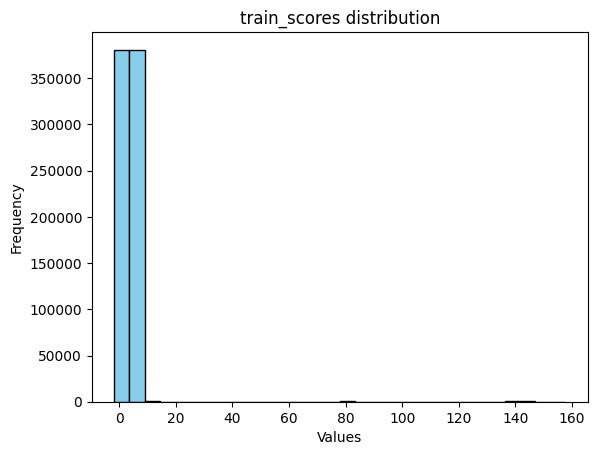

In [8]:
import matplotlib.pyplot as plt
import numpy as np


# Plotting a basic histogram
plt.hist(train_scores, bins=30, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('train_scores distribution')

# Display the plot

In [9]:
validation_scores = model.decision_function(X_validation)
print(np.percentile(validation_scores, [0.1, 1, 5, 50, 95, 99, 99.9]))

188967 rows before feature engineering
188967 rows after merging parent process info
188967 rows after frequency encoding
188967 Null value counts after imputation
parent_timestamp null value count: 43531
188967 rows after processing parent and child process info and relationship
188967 rows after processing stackAddresses info
188967 rows after processing arg info
[-1.28130490e-01 -7.48248322e-03  6.28863948e-03  1.83137307e+00
  4.86220241e+00  5.36175034e+00  1.39473577e+02]


In [10]:
coef = model.named_steps["clf"].coef_.ravel()
features = model.named_steps["scaler"].get_feature_names_out()

importance = sorted(zip(features, coef), key=lambda x: abs(x[1]), reverse=True)

for f, w in importance[:10]:
    print(f, w)

binary__parentUserId_binary 1.5527412502702855
binary__userId_binary 1.5420534257524008
pass__argsNum 1.5213972869717451
rarity__parentProcessId_rarity 0.17615898802335414
count__parentProcessId_past_count 0.14901789379148575
count__eventId_past_count 0.14701933886765325
rarity__eventId_rarity 0.11844353711093031
count__mountNamespace_past_count -0.08518321215689938
count__userId_past_count -0.08481376154629566
count__processId_eventId_past_count 0.06374981332405448


Text(0.5, 1.0, 'validation_scores distribution')

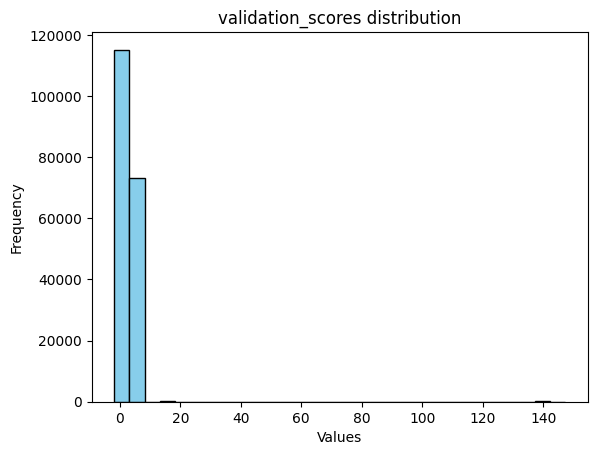

In [11]:
import matplotlib.pyplot as plt
import numpy as np


# Plotting a basic histogram
plt.hist(validation_scores, bins=30, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('validation_scores distribution')

In [12]:
print("Predict on test data...")
# best_threshold = np.percentile(validation_scores, 1)
test_scores = model.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, -test_scores)


for target_fpr in [0.01, 0.02, 0.05, 0.1]:
    idx = (fpr <= target_fpr).nonzero()[0][-1]
    print(f"FPR target {target_fpr}: threshold={thresholds[idx]:.4f}, TPR={tpr[idx]:.4f}")

best_threshold = 0.0237

# best_threshold = np.percentile(validation_scores, 1)
test_scores = model.decision_function(X_test)
y_pred_test = (test_scores < best_threshold).astype(int)



Predict on test data...
188967 rows before feature engineering
188967 rows after merging parent process info
188967 rows after frequency encoding
188967 Null value counts after imputation
parent_timestamp null value count: 8925
188967 rows after processing parent and child process info and relationship
188967 rows after processing stackAddresses info
188967 rows after processing arg info
FPR target 0.01: threshold=1.0620, TPR=0.9313
FPR target 0.02: threshold=0.9181, TPR=0.9409
FPR target 0.05: threshold=-0.0434, TPR=0.9509
FPR target 0.1: threshold=-0.0887, TPR=0.9511
188967 rows before feature engineering
188967 rows after merging parent process info
188967 rows after frequency encoding
188967 Null value counts after imputation
parent_timestamp null value count: 8925
188967 rows after processing parent and child process info and relationship
188967 rows after processing stackAddresses info
188967 rows after processing arg info


### Model Evaluation

y_true_Test Dataset Unique values: [0 1]
y_true_Test Dataset Counts of each value: [ 30535 158432]
y_pred_Test Dataset Unique values: [0 1]
y_pred_Test Dataset Counts of each value: [ 37374 151593]
Confusion Matrix:
[[ 29576    959]
 [  7798 150634]]


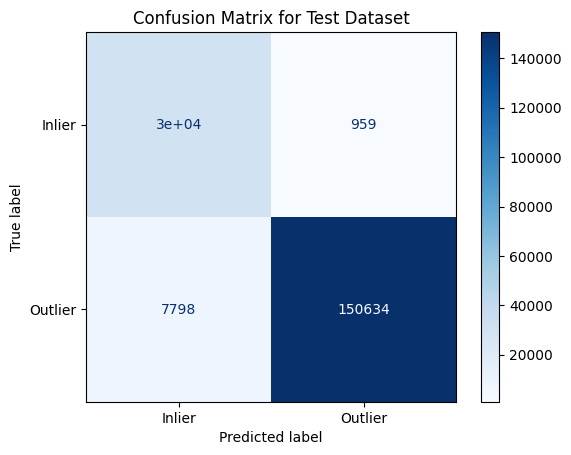

False Positive Rate: [0.         0.03140658 1.        ]
True Positive Rate: [0.         0.95078015 1.        ]


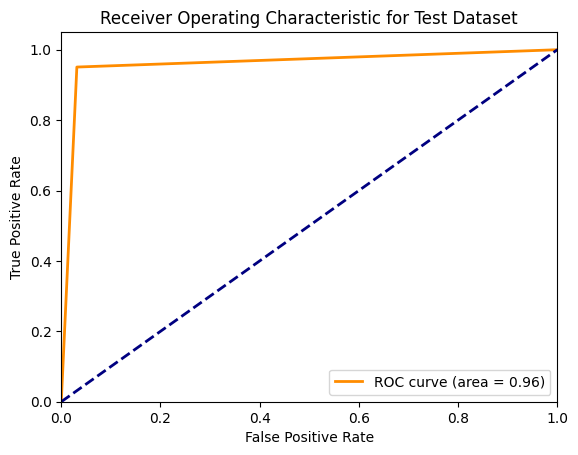

In [13]:
evaluate_model(y_test, y_pred_test, dataset_type="Test Dataset")